In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

In [148]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer

In [168]:
df = pd.read_csv('Housing2.csv')

In [169]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [170]:
df = df[['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement','price']]

In [171]:
df = df.iloc[:1000,:]

In [172]:
df.head()

,sqft_living,sqft_lot,sqft_above,sqft_basement,price
0,1180,5650,1180,0,231300.0
1,2570,7242,2170,400,538000.0
2,770,10000,770,0,180000.0
3,1960,5000,1050,910,604000.0
4,1680,8080,1680,0,510000.0


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sqft_living    1000 non-null   int64  
 1   sqft_lot       1000 non-null   int64  
 2   sqft_above     1000 non-null   int64  
 3   sqft_basement  1000 non-null   int64  
 4   price          1000 non-null   float64
dtypes: float64(1), int64(4)
memory usage: 39.2 KB


In [173]:
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['price']), df['price'], test_size=0.2, random_state=42)

In [73]:
from sklearn.preprocessing import StandardScaler

In [87]:
scaler = StandardScaler()

In [88]:
X_scaled = scaler.fit_transform(X_train)

In [89]:
X_test_scaled = scaler.transform(X_test)

In [90]:
X_train_scaled = pd.DataFrame(X_scaled, columns=['sqft_living','sqft_lot','sqft_above','sqft_basement'])

In [91]:
X_test_scaled = pd.DataFrame(X_test_scaled, columns=['sqft_living','sqft_lot','sqft_above','sqft_basement'])

In [42]:
y_train

29      719000.0
535     358000.0
695     245000.0
557     238000.0
836     430000.0
         ...    
106     460000.0
270    1365000.0
860     245000.0
435     749000.0
102     699950.0
Name: price, Length: 800, dtype: float64

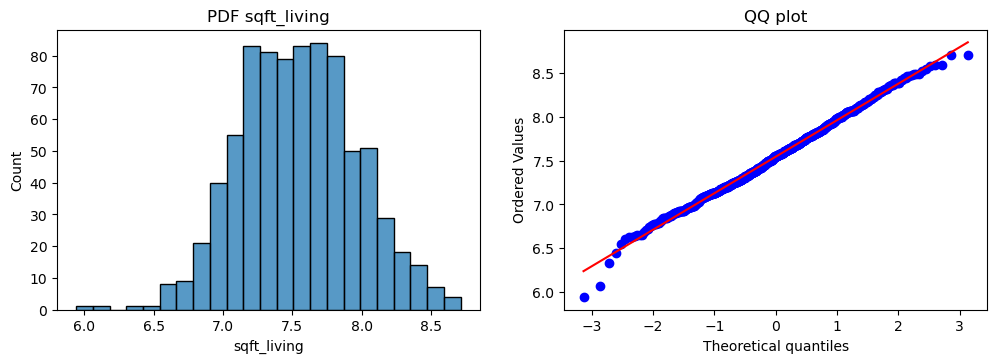

In [94]:
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
sns.histplot(X_train_transformed['sqft_living'])
plt.title('PDF sqft_living')

plt.subplot(2,2,2)
stats.probplot(X_train_transformed['sqft_living'], dist='norm', plot=plt)
plt.title('QQ plot')

plt.show()

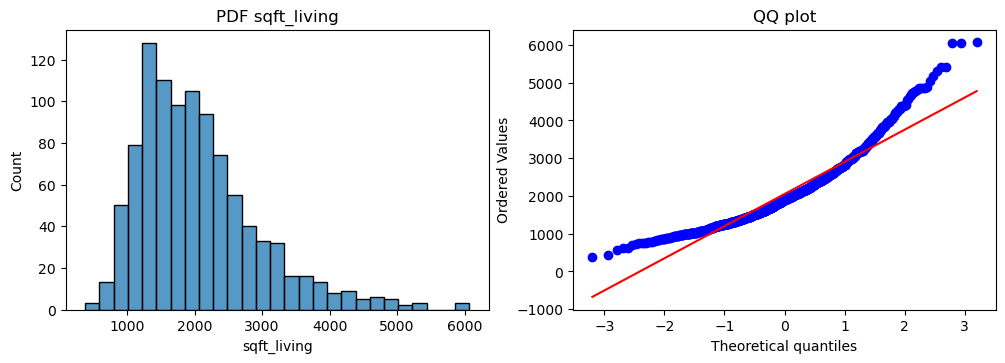

In [21]:
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
sns.histplot(df['sqft_living'])
plt.title('PDF sqft_living')

plt.subplot(2,2,2)
stats.probplot(df['sqft_living'], dist='norm', plot=plt)
plt.title('QQ plot')

plt.show()

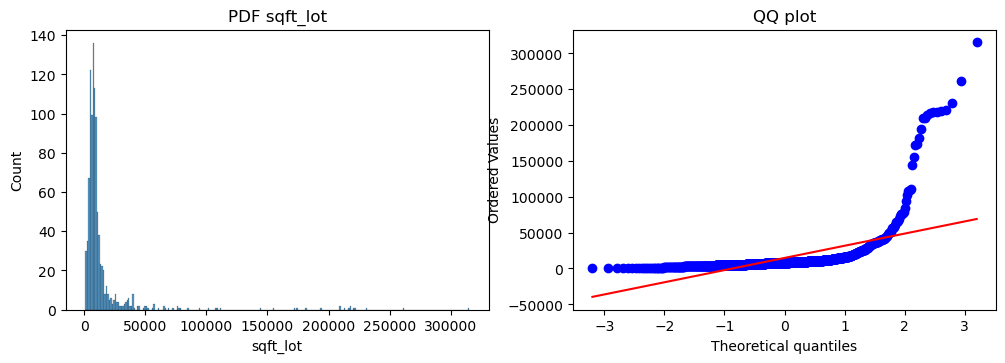

In [55]:
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
sns.histplot(df['sqft_lot'])
plt.title('PDF sqft_lot')

plt.subplot(2,2,2)
stats.probplot(df['sqft_lot'], dist='norm', plot=plt)
plt.title('QQ plot')

plt.show()

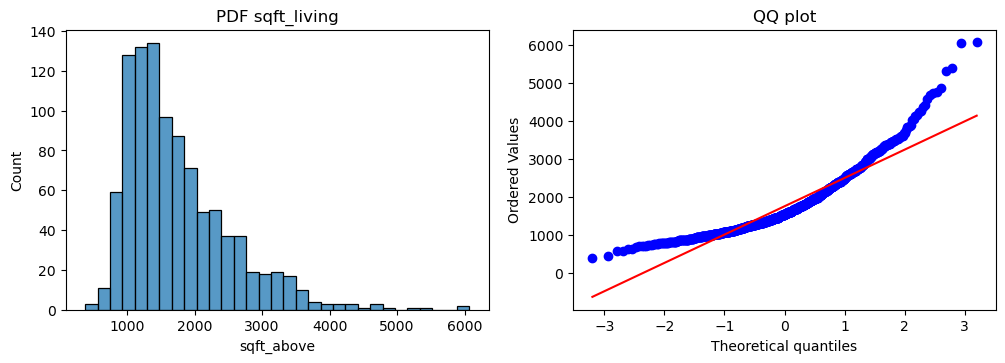

In [56]:
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
sns.histplot(df['sqft_above'])
plt.title('PDF sqft_living')

plt.subplot(2,2,2)
stats.probplot(df['sqft_above'], dist='norm', plot=plt)
plt.title('QQ plot')

plt.show()

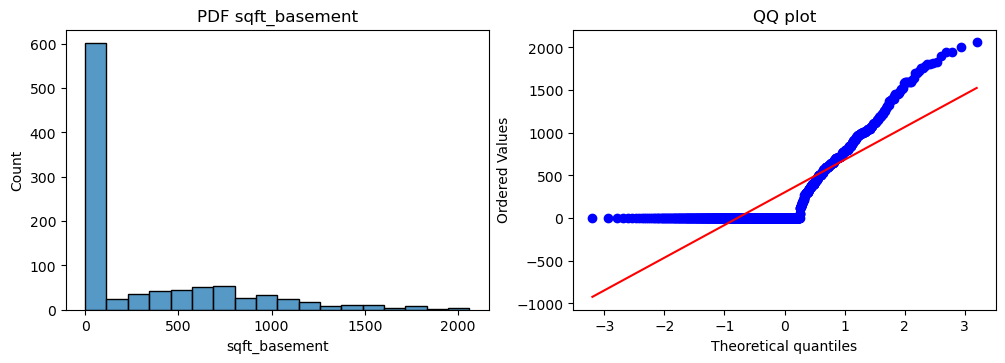

In [57]:
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
sns.histplot(df['sqft_basement'])
plt.title('PDF sqft_basement')

plt.subplot(2,2,2)
stats.probplot(df['sqft_basement'], dist='norm', plot=plt)
plt.title('QQ plot')

plt.show()

In [174]:
lr = LinearRegression()
clr = DecisionTreeRegressor()

In [175]:
lr.fit(X_train_scaled, y_train)
clr.fit(X_train_scaled, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [45]:
X_train

,sqft_living,sqft_lot,sqft_above,sqft_basement
29,2570,7173,2570,0
535,1610,6655,1610,0
695,1410,5760,1410,0
557,1400,7242,1400,0
836,1350,4003,1350,0
...,...,...,...,...
106,1670,4005,1170,500
270,5310,57346,5310,0
860,380,15000,380,0
435,1710,9627,1440,270


In [176]:
lr_pred = lr.predict(X_test_scaled)
clf_pred = clr.predict(X_test_scaled)

In [97]:
print(f"lr_pred: {mean_absolute_error(y_test, lr_pred)}")

lr_pred: 157199.2950411338


In [98]:
mape = np.mean(np.abs((y_test - lr_pred)/y_test))*100

In [99]:
mape

34.20789828344241

In [100]:
mape2 = np.mean(np.abs((y_test - clf_pred)/y_test))*100

In [101]:
mape2

40.466120550690285

In [105]:
trf1 = FunctionTransformer(func=np.log1p)

In [106]:
X_train_transformed = trf1.fit_transform(X_train)

In [107]:
X_test_transformed = trf1.fit_transform(X_test)

In [108]:
scaler = StandardScaler()

In [109]:
X_train_tscale = scaler.fit_transform(X_train_transformed)

In [111]:
X_test_tscale = scaler.transform(X_test_transformed)

In [62]:
X_train_transformed

,sqft_living,sqft_lot,sqft_above,sqft_basement
29,7.852050,8.878219,7.852050,0.000000
535,7.384610,8.803274,7.384610,0.000000
695,7.252054,8.658866,7.252054,0.000000
557,7.244942,8.887791,7.244942,0.000000
836,7.208600,8.295049,7.208600,0.000000
...,...,...,...,...
106,7.421178,8.295549,7.065613,6.216606
270,8.577535,10.956876,8.577535,0.000000
860,5.942799,9.615872,5.942799,0.000000
435,7.444833,9.172431,7.273093,5.602119


In [112]:
lr1 = LinearRegression()
clr2 = DecisionTreeRegressor()

In [113]:
lr1.fit(X_train_tscale, y_train)
clr2.fit(X_train_tscale, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [114]:
y_pred = lr1.predict(X_test_tscale)
clr_y_pred = clr2.predict(X_test_tscale)

In [115]:
mape3 = np.mean(np.abs((y_test - y_pred)/y_test))*100

In [116]:
mape3

37.307190469015254

In [117]:
mape2 = np.mean(np.abs((y_test - clr_y_pred)/y_test))*100

In [118]:
mape2

39.869789984308

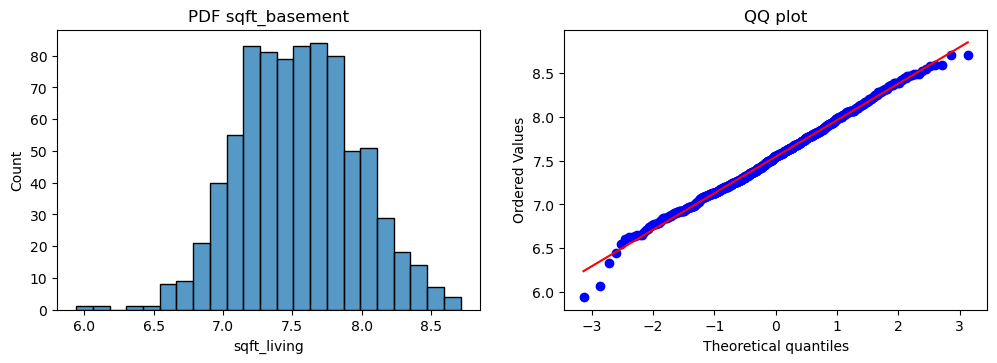

In [72]:
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
sns.histplot(X_train_transformed['sqft_living'])
plt.title('PDF sqft_basement')

plt.subplot(2,2,2)
stats.probplot(X_train_transformed['sqft_living'], dist='norm', plot=plt)
plt.title('QQ plot')

plt.show()

In [134]:
x = df.drop(columns=['price'])

In [137]:
y = df.iloc[:,-1]

In [177]:
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['price']), df['price'], test_size=0.2, random_state=42)

In [178]:
X_train.skew()

sqft_living      1.207191
sqft_lot         6.082659
sqft_above       1.434735
sqft_basement    1.461057
dtype: float64

In [179]:
lr = LinearRegression()

In [180]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [181]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [182]:
r2_score(y_test, y_pred)

0.37273183674564214

In [145]:
lr = LinearRegression()
np.mean(cross_val_score(lr, x, y, cv=10, scoring='r2'))

0.4854794054708801

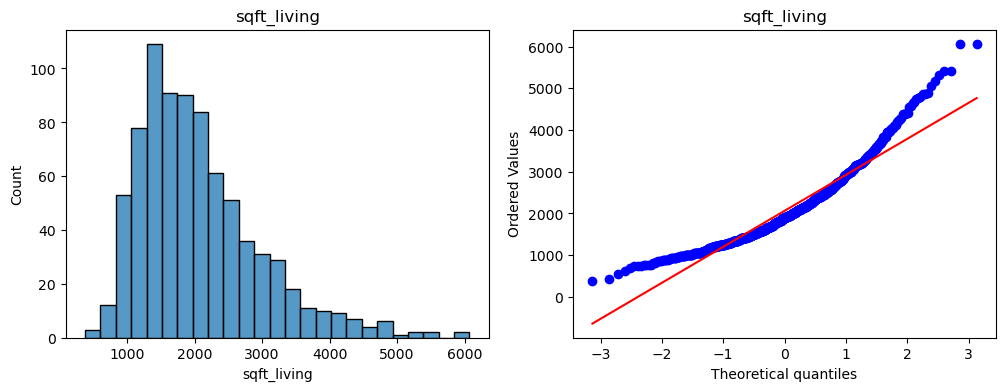

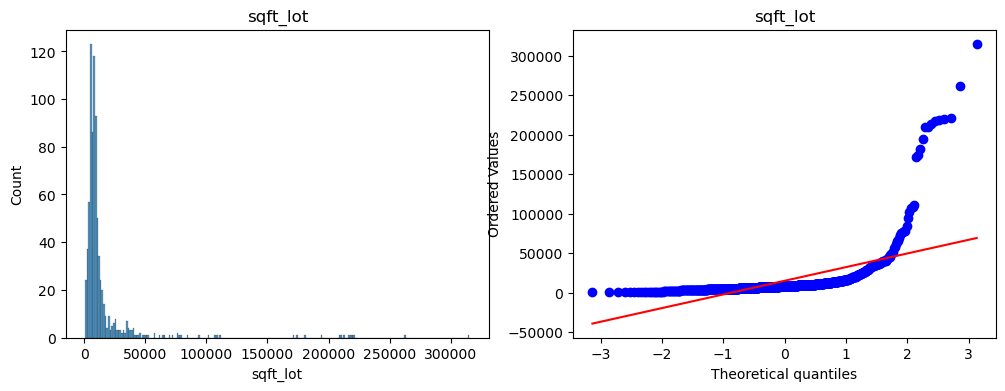

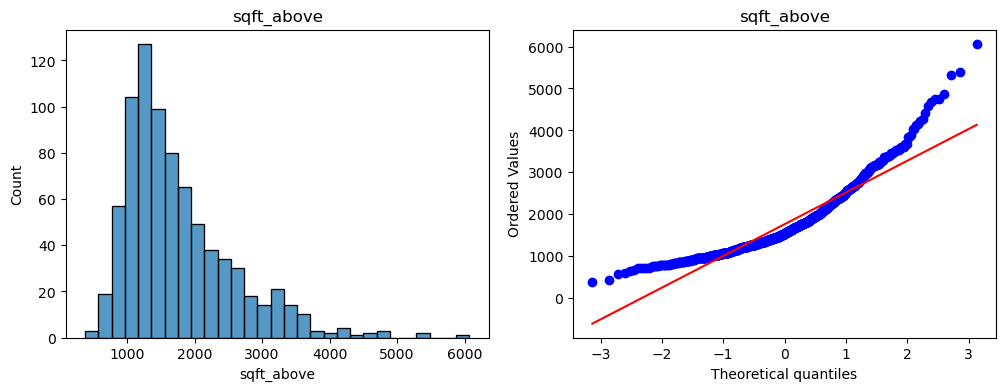

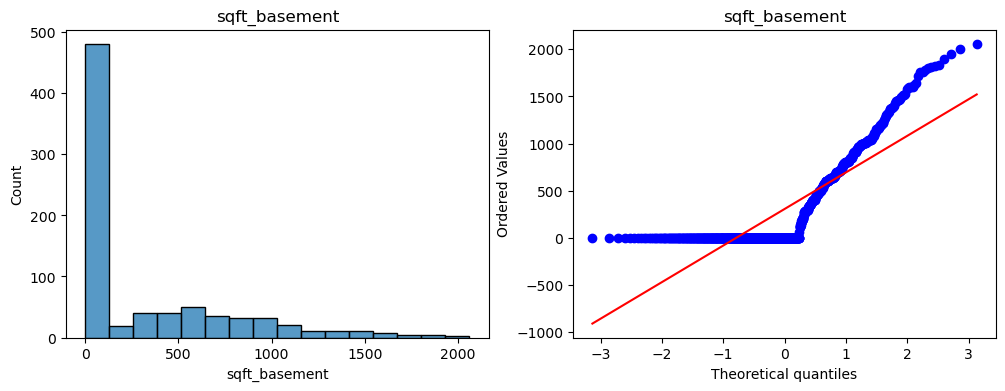

In [147]:
# hist plot before transformation

for col in X_train.columns:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.histplot(X_train[col])
    plt.title(col)

    plt.subplot(1,2,2)
    stats.probplot(X_train[col], dist='norm', plot=plt)
    plt.title(col)
    plt.show()

In [149]:
# applying box-cox transform
pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.0000001)
X_test_transformed = pt.transform(X_test+0.0000001)

pd.DataFrame({'cols':X_train.columns, 'box-cox lambdas': pt.lambdas_})

,cols,box-cox lambdas
0,sqft_living,-0.018549
1,sqft_lot,-0.221519
2,sqft_above,-0.226977
3,sqft_basement,-0.051772


In [185]:
# applying Linear Regression on transformed data

lr = LinearRegression()

lr.fit(X_train_transformed, y_train)
y_pred = lr.predict(X_test_transformed)

r2_score(y_test, y_pred)

0.37273183674564214

In [151]:
# using cross validation

pt = PowerTransformer(method='box-cox')

lr = LinearRegression()

X_transformed = pt.fit_transform(x+0.000001)

np.mean(cross_val_score(lr, X_transformed, y, cv=10, scoring='r2'))

0.3899714132905786

In [157]:
X_train_transformed2 = pd.DataFrame(X_train_transformed, columns=X_train.columns)

In [159]:
X_train_transformed2

,sqft_living,sqft_lot,sqft_above,sqft_basement
0,0.739018,-0.169838,1.122289,-0.824884
1,-0.380789,-0.267111,0.056773,-0.824884
2,-0.700170,-0.459162,-0.266604,-0.824884
3,-0.717329,-0.157530,-0.284232,-0.824884
4,-0.805044,-0.971176,-0.374754,-0.824884
...,...,...,...,...
795,-0.292828,-0.970444,-0.738285,1.200543
796,2.457505,1.974161,2.567187,-0.824884
797,-3.899842,0.706097,-4.046041,-0.824884
798,-0.235957,0.196782,-0.214625,1.170396


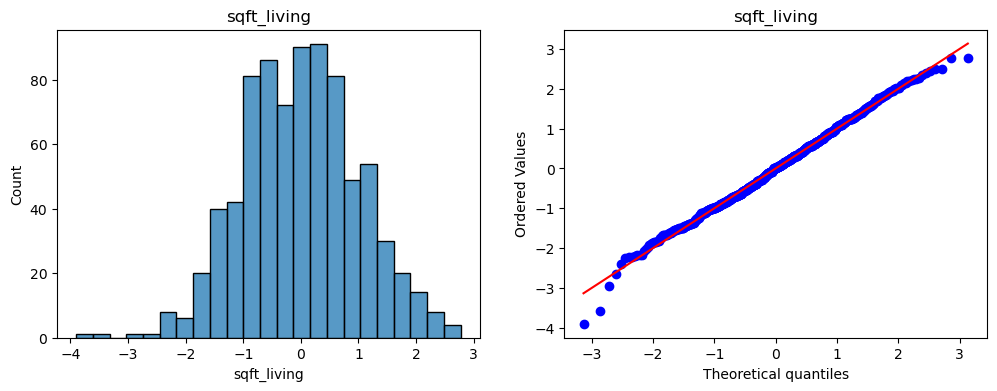

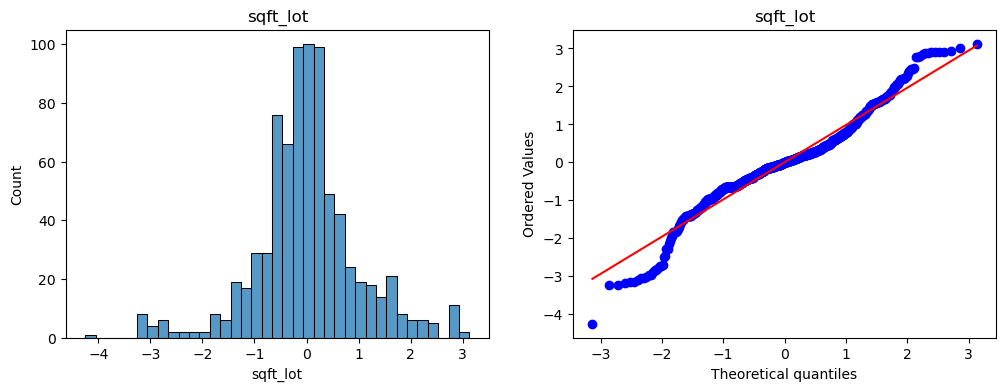

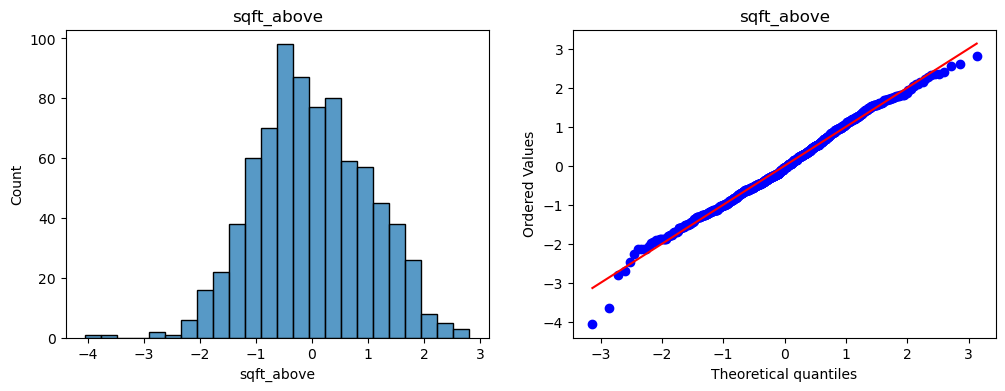

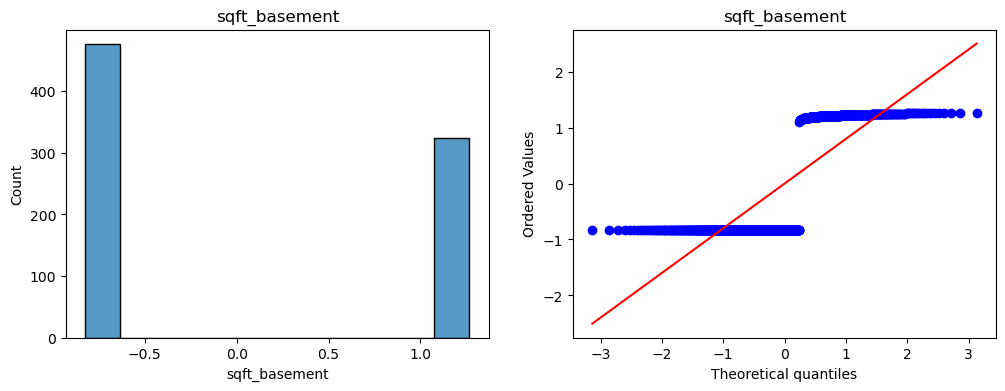

In [160]:
for col in X_train_transformed2.columns:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.histplot(X_train_transformed2[col])
    plt.title(col)

    plt.subplot(1,2,2)
    stats.probplot(X_train_transformed2[col], dist='norm', plot=plt)
    plt.title(col)
    plt.show()

<Axes: xlabel='sqft_living', ylabel='price'>

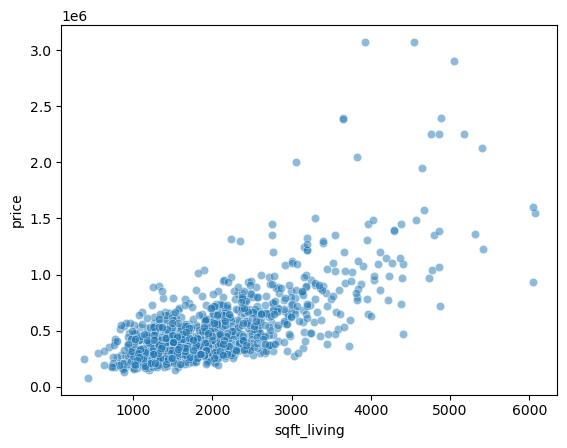

In [164]:
sns.scatterplot(x='sqft_living', y='price', data=df, alpha=0.5)

In [186]:
# applying yeo johnson transformation

pt = PowerTransformer()

X_train_transformed = pt.fit_transform(X_train)
X_test_transformed = pt.transform(X_test)

In [188]:
lr = LinearRegression()

lr.fit(X_train_transformed, y_train)
y_pred = lr.predict(X_test_transformed)

r2_score(y_test, y_pred)

0.37273183674564214